# Multi-species LSTM — sample-efficiency and cross-species borrowing

**Question.** When a focal species has very few training examples, how much can a
pooled model *borrow* from other species — and does a phylogenetic context embedding
allow borrowing more effectively than a one-hot embedding or no context at all?

**Design.**
Fix one focal species (default: Apple).  Train all models on the 6 other species
plus a random subsample of *N* observations from the focal species.  Vary *N* from
0 (pure cross-species transfer) up to the full training set.  Repeat each *N* with
multiple random subsamples to obtain error bands.

| Model | Training data | Species context for focal species |
|---|---|---|
| `pool_plain`  | 6 species + N focal | none |
| `pool_onehot` | 6 species + N focal | zero vector when N=0, one-hot when N>0 |
| `pool_phylo`  | 6 species + N focal | phylogenetic MDS coords (always available) |
| `single`      | N focal only        | — |

At *N*=0 the pool models receive no focal-species training examples; the single
model is undefined and omitted.  The gap between pool and single at small *N*
quantifies how much knowledge is borrowed from other species.

In [1]:
FOCAL_SPECIES = 'Apple'   # which species to subsample
CUTOFF        = 2006      # years < CUTOFF → train,  ≥ CUTOFF → test

# Subsample sizes; None = full training set (1 repeat only, no variance)
N_VALUES  = [0, 10, 25, 50, 100, 250, 500, 1000, 2000, None]
N_REPEATS = 5    # random subsamples per N  (1 repeat used for N=0 and N=None)

RETRAIN = False

DATASETS_CONFIG = {
    'Apple':   dict(key='PEP725_Apple',   obs_key='BBCH_60', name='Malus x domestica'),
    'Pear':    dict(key='PEP725_Pear',    obs_key='BBCH_60', name='Pyrus communis'),
    'Peach':   dict(key='PEP725_Peach',   obs_key='BBCH_60', name='Prunus persica'),
    'Almond':  dict(key='PEP725_Almond',  obs_key='BBCH_60', name='Prunus amygdalis'),
    'Cherry':  dict(key='PEP725_Cherry',  obs_key='BBCH_60', name='Prunus avium'),
    'Apricot': dict(key='PEP725_Apricot', obs_key='BBCH_60', name='Prunus armeniaca'),
    'Plum':    dict(key='PEP725_Plum',    obs_key='BBCH_60', name='Prunus domestica'),
}

DATA_KEYS     = ['temperature_2m_mean', 'daylight_duration']
PHYLO_K_EMBED = len(DATASETS_CONFIG)

MODEL_KWARGS = dict(
    data_keys   = DATA_KEYS,
    hidden_size = 64,
    num_layers  = 2,
)
TRAIN_KWARGS = dict(
    num_epochs               = 100,
    batch_size               = 32,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 20,
    scheduler_decay          = 0.5,
    early_stopping           = True,
    early_stopping_patience  = 25,
    early_stopping_min_delta = 1e-4,
    early_stopping_rerun     = False,
    seed                     = 0,
    verbose                  = False,
)

In [2]:
import warnings
warnings.filterwarnings('ignore')

from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.dataset.util.phylogeny import PhylogenyFeatures
from pysephone.models.lstm import LSTMModel
from pysephone.models.lstm_ctx import OneHotSpeciesLSTMModel, PhylogeneticLSTMModel
from pysephone.paths import get_data_root, get_model_dir

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 1. Load datasets

In [3]:
def target_fn(sample):
    return sample['observations']['BBCH_60']


cal = Calendar()

per_species_trn: dict[str, Dataset] = {}
per_species_tst: dict[str, Dataset] = {}

for label, cfg in DATASETS_CONFIG.items():
    cache = FeatureCache.load(FeatureCache.default_path(cfg['key'], DATA_KEYS))
    ds    = Dataset.load(cfg['key'], calendar=cal, feature_providers=[cache])
    ys_trn = [y for y in ds.years if y <  CUTOFF]
    ys_tst = [y for y in ds.years if y >= CUTOFF]
    per_species_trn[label] = ds.select_years(ys_trn)
    per_species_tst[label] = ds.select_years(ys_tst)
    print(f'{label}: train={len(per_species_trn[label])}  test={len(per_species_tst[label])}')

focal_trn_full = per_species_trn[FOCAL_SPECIES]
focal_tst      = per_species_tst[FOCAL_SPECIES]
print(f'\nFocal species: {FOCAL_SPECIES}  ({len(focal_trn_full)} train / {len(focal_tst)} test)')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 44049.31it/s]


Apple: train=4154  test=2607


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 46633.16it/s]


Pear: train=979  test=2305


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 44094.55it/s]


...

Cherry: train=4768  test=2797


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 42156.24it/s]


Apricot: train=15  test=175


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 42713.85it/s]


Plum: train=2420  test=684

Focal species: Apple  (4154 train / 2607 test)


## 2. Fit phylogenetic embedding and load pooled cache

In [4]:
_pool_cache = FeatureCache.load(FeatureCache.default_path('PEP725_fruit_trees', DATA_KEYS))

all_obs = reduce(
    Observations.merge,
    [per_species_trn[l]._obs for l in DATASETS_CONFIG],
)
phylo = PhylogenyFeatures(k_embed=PHYLO_K_EMBED, output=['mds']).fit(all_obs)
species_keys_all = list(phylo.species_keys)
mds_coords_all   = np.asarray(phylo.mds_coords)

print(f'Phylo fitted on {len(species_keys_all)} species, MDS shape: {mds_coords_all.shape}')

Phylo fitted on 7 species, MDS shape: (7, 6)


## 3. Helpers

In [5]:
def train_or_load(model_name, model_cls, model_kwargs, dataset):
    path = get_model_dir(get_data_root(), model_name) / f'{model_name}.pt'
    if not RETRAIN and path.exists():
        model = torch.load(path, weights_only=False, map_location=DEVICE)
        model.eval()
        return model
    model, _ = model_cls.fit(
        target_fn    = target_fn,
        dataset      = dataset,
        model_kwargs = model_kwargs,
        device       = DEVICE,
        **TRAIN_KWARGS,
    )
    model.save(model_name)
    model.eval()
    return model


def evaluate(model, dataset):
    if hasattr(model, 'to'):
        model.to(DEVICE)
    errors = []
    for sample in dataset.iter_items():
        try:
            target_date = target_fn(sample)
        except KeyError:
            continue
        pred_date, _ = model.predict(sample, device=DEVICE)
        season_start = np.datetime64(sample['season_start'], 'D')
        t_ix = int((np.datetime64(target_date, 'D') - season_start) / np.timedelta64(1, 'D'))
        p_ix = int((np.datetime64(pred_date,   'D') - season_start) / np.timedelta64(1, 'D'))
        errors.append(abs(p_ix - t_ix))
    return float(np.mean(errors)) if errors else float('nan')

## 4. Subsampling experiment

For each subsample size *N* and each repetition, build a pooled dataset containing
the 6 background species plus *N* randomly chosen observations from the focal
species, then train and evaluate all model types.

In [6]:
other_obs_list = [per_species_trn[l]._obs for l in DATASETS_CONFIG if l != FOCAL_SPECIES]
focal_ixs_all  = list(focal_trn_full.iter_index())
n_focal_full   = len(focal_ixs_all)

# Replace None with actual full size
n_values_resolved = [n_focal_full if n is None else n for n in N_VALUES]

# {N: {model_name: [mae_rep0, mae_rep1, ...]}}
results: dict[int, dict[str, list[float]]] = {}

MODEL_TYPES = ['pool_plain', 'pool_onehot', 'pool_phylo', 'single']

for N in n_values_resolved:
    # N=0 and N=full: no subsampling variance, 1 rep each
    n_reps = 1 if (N == 0 or N >= n_focal_full) else N_REPEATS
    results[N] = {m: [] for m in MODEL_TYPES}
    print(f'\nN={N}  ({n_reps} rep(s))')

    for rep in range(n_reps):
        rng = np.random.default_rng(rep)

        # ── Subsample focal species ──────────────────────────────────────
        if N == 0:
            focal_obs_sub = None
        elif N >= n_focal_full:
            focal_obs_sub = focal_trn_full._obs
        else:
            chosen_ixs = [focal_ixs_all[i]
                          for i in rng.choice(n_focal_full, size=N, replace=False)]
            focal_obs_sub = focal_trn_full._obs.select_by_ixs(chosen_ixs)

        # ── Pooled training dataset ──────────────────────────────────────
        pool_parts = other_obs_list + ([focal_obs_sub] if focal_obs_sub is not None else [])
        ds_pool    = Dataset(
            reduce(Observations.merge, pool_parts),
            calendar          = cal,
            feature_providers = [_pool_cache],
        )

        # Species keys present in this pool (for one-hot)
        pool_species = {(str(ix[0]), int(ix[3])) for ix in ds_pool.iter_index()}
        species_keys_pool = [k for k in species_keys_all if k in pool_species]

        # ── Train ────────────────────────────────────────────────────────
        tag = f'subsamp_{FOCAL_SPECIES.lower()}_N{N:05d}_r{rep}'

        plain  = train_or_load(f'{tag}_plain',  LSTMModel,
                               dict(MODEL_KWARGS), ds_pool)
        onehot = train_or_load(f'{tag}_onehot', OneHotSpeciesLSTMModel,
                               dict(MODEL_KWARGS, species_keys=species_keys_pool), ds_pool)
        phylo_m = train_or_load(f'{tag}_phylo', PhylogeneticLSTMModel,
                                dict(MODEL_KWARGS, species_keys=species_keys_all,
                                     mds_coords=mds_coords_all), ds_pool)

        # ── Evaluate on focal species test set ───────────────────────────
        results[N]['pool_plain'].append(evaluate(plain,   focal_tst))
        results[N]['pool_onehot'].append(evaluate(onehot, focal_tst))
        results[N]['pool_phylo'].append(evaluate(phylo_m, focal_tst))

        # Single: train on the N focal observations only
        if focal_obs_sub is not None:
            ds_focal = Dataset(
                focal_obs_sub,
                calendar          = cal,
                feature_providers = [_pool_cache],
            )
            single = train_or_load(f'{tag}_single', LSTMModel,
                                   dict(MODEL_KWARGS), ds_focal)
            results[N]['single'].append(evaluate(single, focal_tst))

        print(f'  rep {rep}  '
              f'plain={results[N]["pool_plain"][-1]:.1f}  '
              f'onehot={results[N]["pool_onehot"][-1]:.1f}  '
              f'phylo={results[N]["pool_phylo"][-1]:.1f}'
              + (f'  single={results[N]["single"][-1]:.1f}' if results[N]['single'] else ''))

print('\nDone.')


N=0  (1 rep(s))
  rep 0  plain=8.1  onehot=11.8  phylo=53.2

N=10  (5 rep(s))
  rep 0  plain=8.6  onehot=7.6  phylo=5.8  single=4.8
  rep 1  plain=6.9  onehot=6.4  phylo=5.6  single=4.7
  rep 2  plain=8.6  onehot=6.5  phylo=5.7  single=5.9
  rep 3  plain=8.7  onehot=7.5  phylo=4.6  single=4.8
  rep 4  plain=7.3  onehot=8.1  phylo=7.5  single=6.5

N=25  (5 rep(s))
  rep 0  plain=8.4  onehot=5.2  phylo=4.0  single=5.4
  rep 1  plain=8.6  onehot=4.3  phylo=3.8  single=5.2
  rep 2  plain=8.3  onehot=4.3  phylo=4.0  single=5.5
  rep 3  plain=9.9  onehot=5.7  phylo=4.5  single=4.9
  rep 4  plain=8.2  onehot=5.1  phylo=4.9  single=4.9

N=50  (5 rep(s))
  rep 0  plain=7.7  onehot=4.6  phylo=4.3  single=5.1
  rep 1  plain=8.4  onehot=4.3  phylo=3.8  single=4.8
  rep 2  plain=8.1  onehot=4.2  phylo=4.0  single=5.0
  rep 3  plain=8.9  onehot=4.2  phylo=4.1  single=5.6
  rep 4  plain=7.8  onehot=4.0  phylo=4.7  single=5.8

N=100  (5 rep(s))
  rep 0  plain=8.7  onehot=3.8  phylo=3.6  single=4.6
  

## 5. Learning curves

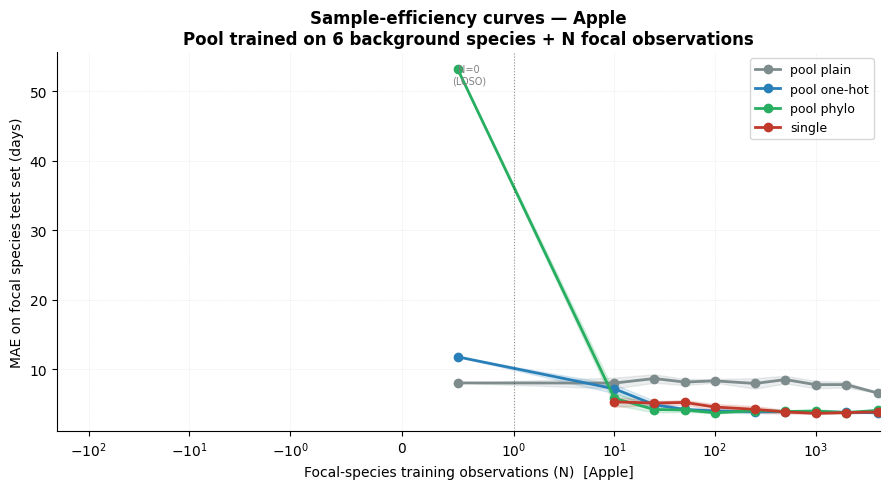

In [7]:
MODEL_COLORS = {
    'pool_plain':  '#7f8c8d',
    'pool_onehot': '#2980b9',
    'pool_phylo':  '#27ae60',
    'single':      '#c0392b',
}
MODEL_LABELS = {
    'pool_plain':  'pool plain',
    'pool_onehot': 'pool one-hot',
    'pool_phylo':  'pool phylo',
    'single':      'single',
}

ns_sorted = sorted(results.keys())

fig, ax = plt.subplots(figsize=(9, 5))

for model_name in MODEL_TYPES:
    xs, means, stds = [], [], []
    for N in ns_sorted:
        vals = results[N][model_name]
        if not vals:
            continue
        xs.append(N if N > 0 else 0.5)   # shift N=0 slightly right of y-axis
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    if not xs:
        continue
    xs    = np.array(xs)
    means = np.array(means)
    stds  = np.array(stds)

    color = MODEL_COLORS[model_name]
    ax.plot(xs, means, marker='o', lw=2, color=color, label=MODEL_LABELS[model_name])
    ax.fill_between(xs, means - stds, means + stds, color=color, alpha=0.15)

# Mark N=0 region
ax.axvline(x=1, color='k', lw=0.8, ls=':', alpha=0.4)
ax.text(0.6, ax.get_ylim()[1] * 0.97, 'N=0\n(LOSO)', ha='center', va='top',
        fontsize=7, color='gray')

ax.set_xscale('symlog', linthresh=1)
ax.set_xlabel(f'Focal-species training observations (N)  [{FOCAL_SPECIES}]')
ax.set_ylabel('MAE on focal species test set (days)')
ax.set_title(
    f'Sample-efficiency curves — {FOCAL_SPECIES}\n'
    'Pool trained on 6 background species + N focal observations',
    fontweight='bold',
)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Borrowing gap

The *borrowing gap* is the MAE difference between a single-species model trained on *N*
focal observations and the best pool model at the same *N*.  A positive gap means the
pool model outperforms single — i.e., cross-species knowledge is net beneficial.

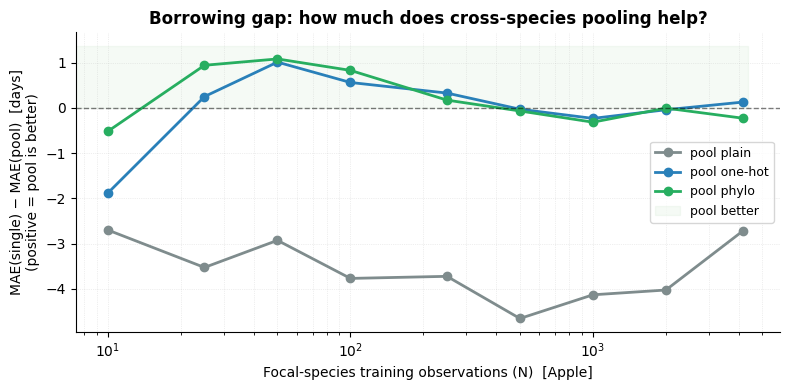

: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ns_with_single = [N for N in ns_sorted if results[N]['single']]

for model_name in ['pool_plain', 'pool_onehot', 'pool_phylo']:
    gaps, xs = [], []
    for N in ns_with_single:
        single_mae = np.mean(results[N]['single'])
        pool_mae   = np.mean(results[N][model_name])
        if not np.isnan(single_mae) and not np.isnan(pool_mae):
            gaps.append(single_mae - pool_mae)   # positive → pool is better
            xs.append(N)
    if xs:
        ax.plot(xs, gaps, marker='o', lw=2,
                color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name])

ax.axhline(0, color='k', lw=1, ls='--', alpha=0.5)
ax.fill_between(ax.get_xlim(), 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
                color='green', alpha=0.04, label='pool better')

ax.set_xscale('log')
ax.set_xlabel(f'Focal-species training observations (N)  [{FOCAL_SPECIES}]')
ax.set_ylabel('MAE(single) − MAE(pool)  [days]\n(positive = pool is better)')
ax.set_title('Borrowing gap: how much does cross-species pooling help?',
             fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.4)
plt.tight_layout()
plt.show()